In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from tqdm import trange
from torch import nn

import torch
import torch.distributions as D

In [2]:
torch.manual_seed(0)

n_groups = 2
group_rank = 3
n_components = n_groups * group_rank
obs_dim = 20
n_time_bins = 1000
kernel_size = 1
kernel = torch.exp(torch.arange(kernel_size).float())
kernel = kernel / kernel.sum()

torch.Size([2000, 6])


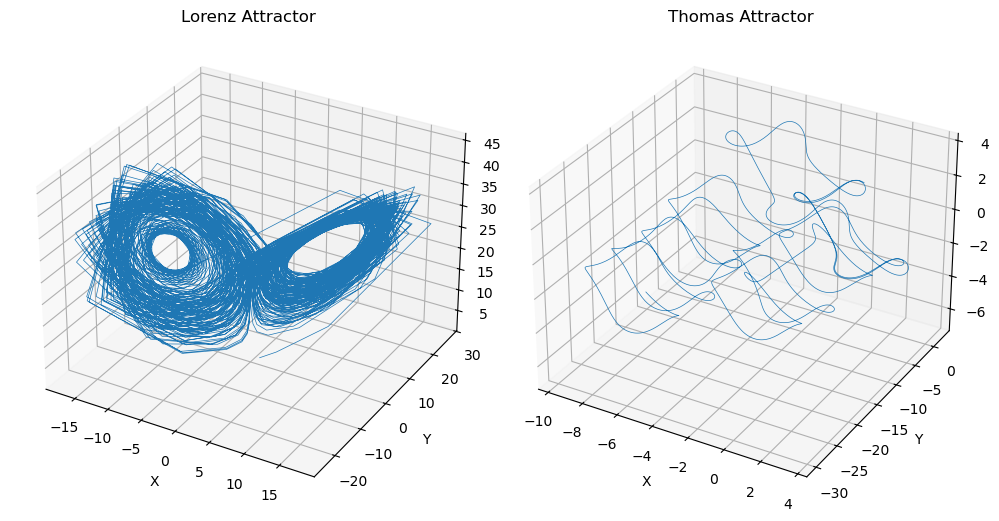

In [3]:
# Lorenz系统导数
def lorenz_deriv(pos, sigma=10.0, rho=28.0, beta=8.0 / 3):
    x, y, z = pos[..., 0], pos[..., 1], pos[..., 2]
    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = x * y - beta * z
    return torch.stack([dx, dy, dz], dim=-1)


# Rossler系统导数
def rossler_deriv(pos, a=0.2, b=0.2, c=5.7):
    x, y, z = pos[..., 0], pos[..., 1], pos[..., 2]
    dx = -y - z
    dy = x + a * y
    dz = b + z * (x - c)
    return torch.stack([dx, dy, dz], dim=-1)


def thomas_deriv(pos, b=0):
    x, y, z = pos[..., 0], pos[..., 1], pos[..., 2]
    dx = -torch.sin(y) - b * x
    dy = torch.sin(z) - b * y
    dz = torch.sin(x) - b * z
    return torch.stack([dx, dy, dz], dim=-1)


# 通用RK4一步
def rk4_step(f, pos, dt):
    k1 = f(pos)
    k2 = f(pos + dt / 2 * k1)
    k3 = f(pos + dt / 2 * k2)
    k4 = f(pos + dt * k3)
    return pos + dt / 6 * (k1 + 2 * k2 + 2 * k3 + k4)


# 初始化
n_steps = 2 * n_time_bins
dt = 0.1

# 初始状态 (6维：前3是Lorenz，后3是Rossler)
z = torch.zeros((n_steps, 6))
z[0, :3] = torch.tensor([1.0, 1.0, 1.0])  # Lorenz初值
# z[0, 3:] = torch.tensor([1.0, 1.0, 1.0])  # Rossler初值
z[0, 3:] = torch.tensor([0.1, 1.0, 1.0])  # Thomas初值

# 时间演化
for t in range(n_steps - 1):
    lorenz_part = rk4_step(lorenz_deriv, z[t, :3], dt)
    # rossler_part = rk4_step(rossler_deriv, z[t, 3:], dt)
    thomas_part = rk4_step(thomas_deriv, z[t, 3:], dt)
    z[t + 1, :3] = lorenz_part
    # z[t + 1, 3:] = rossler_part
    z[t + 1, 3:] = thomas_part

# 检查形状
print(z.shape)  # 应该是 (2000, 6)

# 画一画
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(121, projection="3d")
ax.plot(z[:, 0], z[:, 1], z[:, 2], lw=0.5)
ax.set_title("Lorenz Attractor")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

ax2 = fig.add_subplot(122, projection="3d")
ax2.plot(z[:, 3], z[:, 4], z[:, 5], lw=0.5)
ax2.set_title("Thomas Attractor")
ax2.set_xlabel("X")
ax2.set_ylabel("Y")
ax2.set_zlabel("Z")

plt.tight_layout()
plt.show()

fig.savefig("synthetic_data_1.pdf", transparent=True)

In [4]:
z = (z - z.mean(dim=0)) / z.std(dim=0)

In [5]:
x_input = torch.randn(n_steps, obs_dim) * 5e-3

In [6]:
class ARDecompositionNet(nn.Module):
    def __init__(self, n_components, obs_dim, kernel):
        super().__init__()
        self.n_components = n_components
        self.obs_dim = obs_dim
        self.kernel = kernel

        self.linear_decoder = nn.Linear(n_components, obs_dim)
        self.linear_encoder = nn.Linear(obs_dim, n_components)

    def forward(self, z_history, x_input):
        # z_history: (batch_size, kernel_size, n_components)
        x = self.linear_decoder(z_history)
        x = torch.tanh(x)
        x = torch.einsum("L,BLK->BK", self.kernel, x)
        x = x + x_input
        z = self.linear_encoder(x)  # (batch_size, n_components)
        return z

In [7]:
z_input = torch.stack(
    [z[i : 2 * n_time_bins - kernel_size + i] for i in range(kernel_size)], dim=-2
)
z_output = z[kernel_size:]

In [8]:
torch.manual_seed(0)
model = ARDecompositionNet(n_components, obs_dim, kernel)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

for epoch in range(10000):
    optimizer.zero_grad()
    z_hat = model(z_input, x_input[:1999])
    loss = loss_fn(z_hat, z_output)
    loss.backward()
    optimizer.step()
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 1.0906
Epoch 100, Loss: 0.4030
Epoch 200, Loss: 0.2134
Epoch 300, Loss: 0.1696
Epoch 400, Loss: 0.1441
Epoch 500, Loss: 0.1122
Epoch 600, Loss: 0.0821
Epoch 700, Loss: 0.0609
Epoch 800, Loss: 0.0477
Epoch 900, Loss: 0.0389
Epoch 1000, Loss: 0.0323
Epoch 1100, Loss: 0.0271
Epoch 1200, Loss: 0.0230
Epoch 1300, Loss: 0.0199
Epoch 1400, Loss: 0.0173
Epoch 1500, Loss: 0.0153
Epoch 1600, Loss: 0.0135
Epoch 1700, Loss: 0.0121
Epoch 1800, Loss: 0.0110
Epoch 1900, Loss: 0.0100
Epoch 2000, Loss: 0.0092
Epoch 2100, Loss: 0.0084
Epoch 2200, Loss: 0.0078
Epoch 2300, Loss: 0.0073
Epoch 2400, Loss: 0.0068
Epoch 2500, Loss: 0.0063
Epoch 2600, Loss: 0.0059
Epoch 2700, Loss: 0.0055
Epoch 2800, Loss: 0.0052
Epoch 2900, Loss: 0.0048
Epoch 3000, Loss: 0.0045
Epoch 3100, Loss: 0.0043
Epoch 3200, Loss: 0.0040
Epoch 3300, Loss: 0.0038
Epoch 3400, Loss: 0.0036
Epoch 3500, Loss: 0.0034
Epoch 3600, Loss: 0.0032
Epoch 3700, Loss: 0.0031
Epoch 3800, Loss: 0.0029
Epoch 3900, Loss: 0.0028
Epoch 4000, 

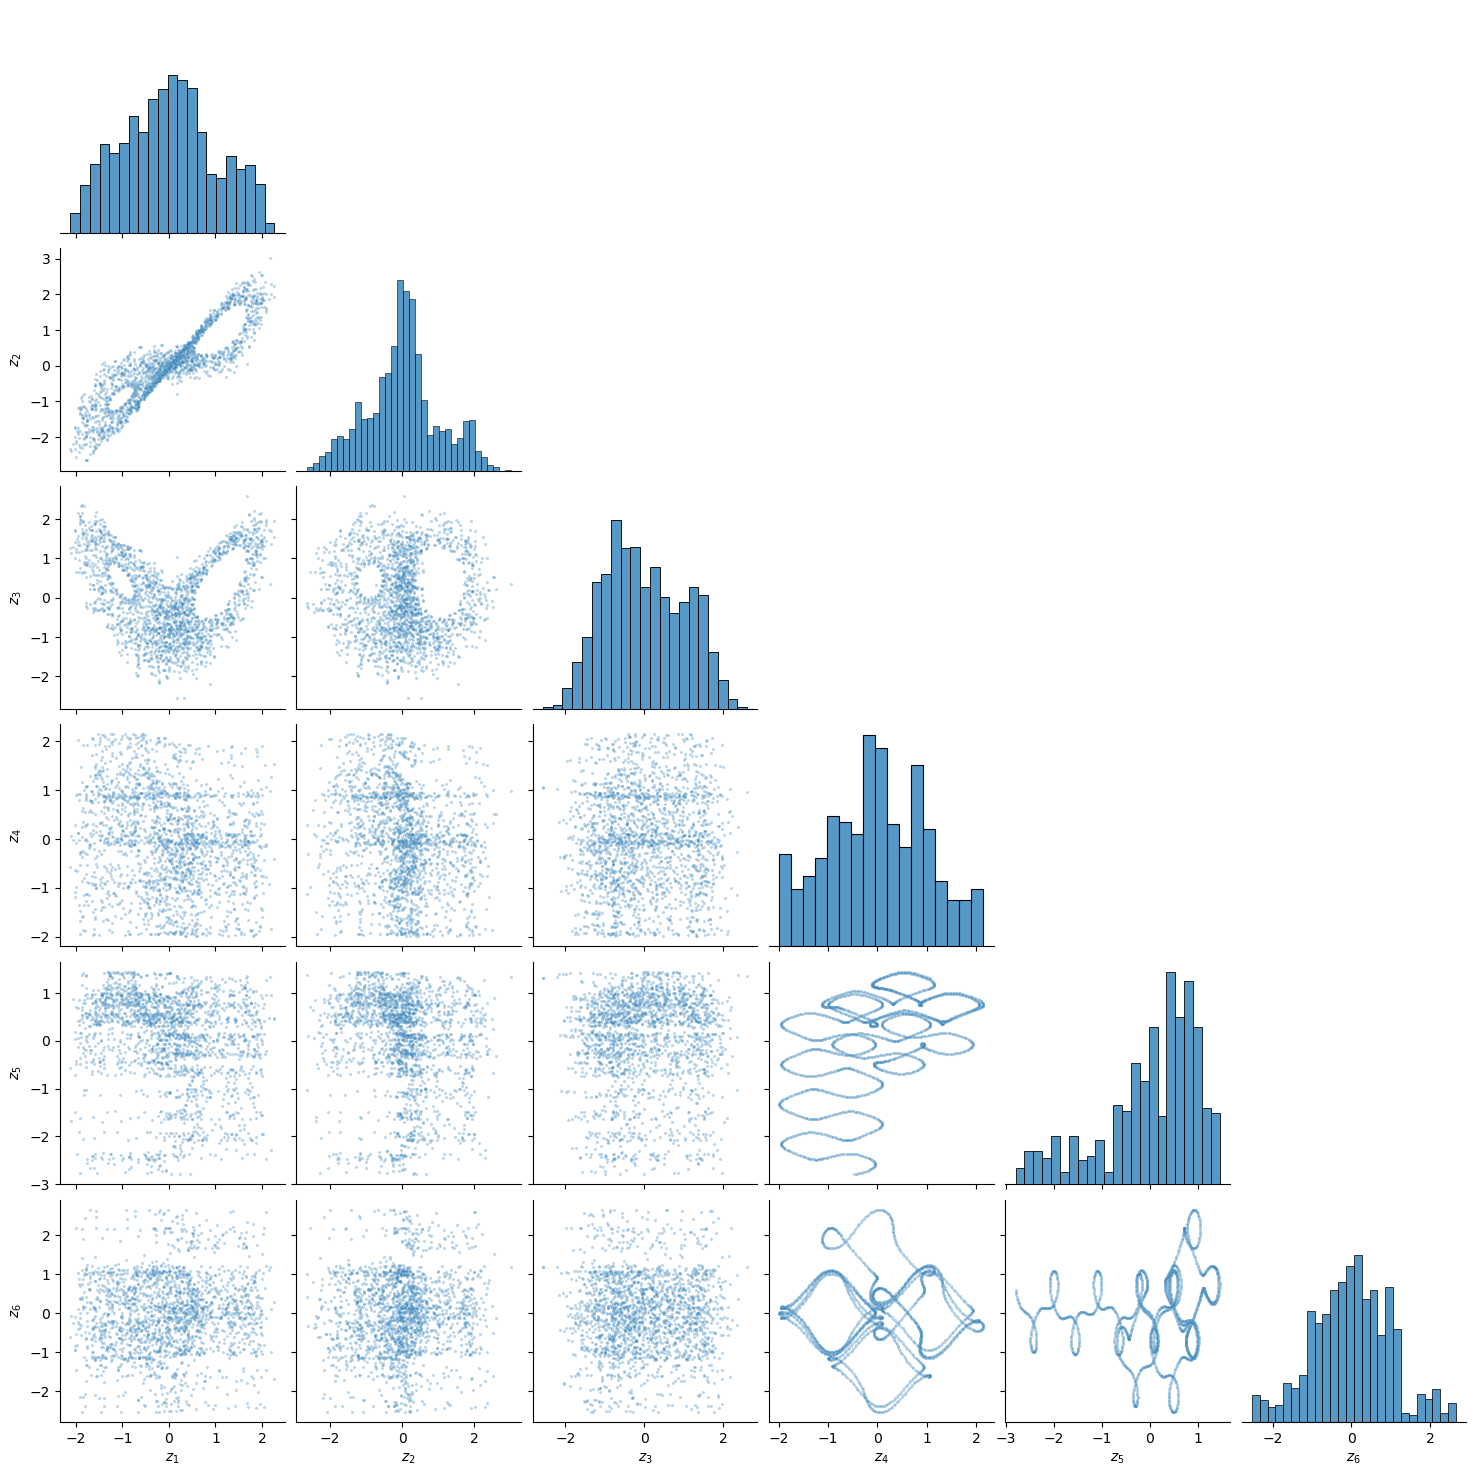

In [9]:
df_temp = pd.DataFrame(z.numpy(), columns=[f"$z_{i+1}$" for i in range(z.shape[1])])
sns.pairplot(df_temp, corner=True, plot_kws=dict(s=5, alpha=0.3))
plt.show()

Text(0.5, 0.01, 'Time')

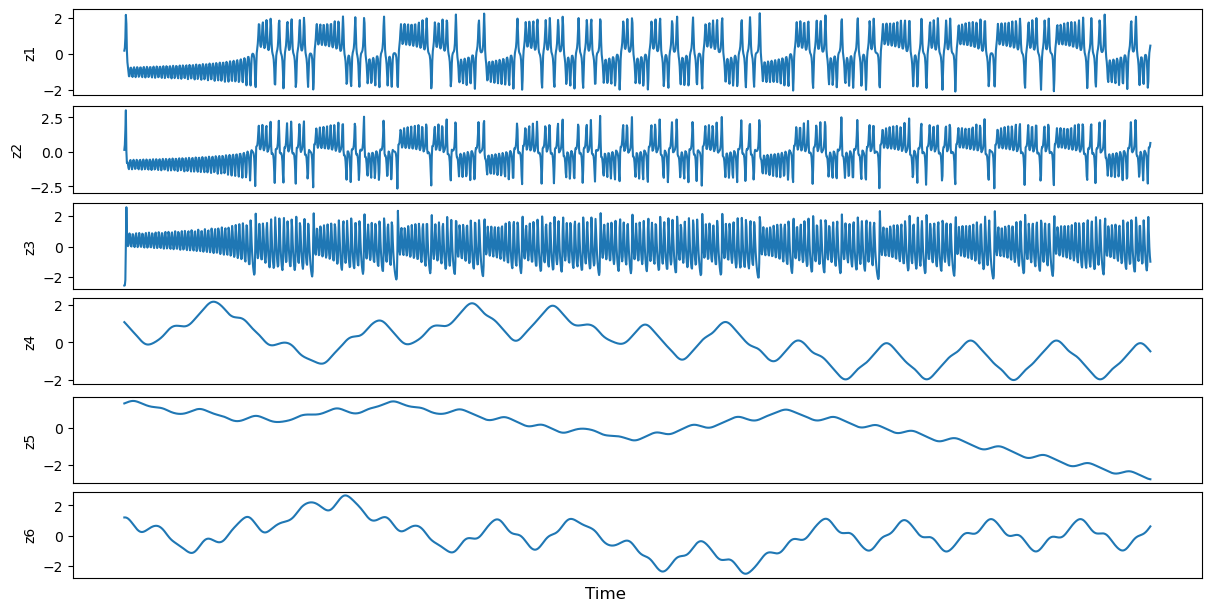

In [10]:
fig, axs = plt.subplots(
    n_components, 1, figsize=(12, 1 * n_components), layout="constrained", sharex=True
)
for i in range(n_components):
    axs[i].plot(z[:, i])
    axs[i].set(xticks=[], ylabel=f"z{i+1}")
fig.supxlabel("Time")

In [11]:
with torch.no_grad():
    print(model.linear_decoder.weight)

Parameter containing:
tensor([[ 1.6965e-01, -2.8637e-03, -7.6690e-01, -7.6411e-03,  1.5259e-02,
         -1.5088e-02],
        [ 2.9987e-01,  4.2429e-01, -2.9318e-01,  2.3801e-03,  4.5679e-03,
          8.0819e-04],
        [-7.1829e-01, -4.0453e-01, -2.5996e-01, -2.4874e-03,  1.1742e-03,
          1.6175e-03],
        [-4.2133e-01, -3.7016e-01,  3.4600e-01, -1.3676e-03, -4.8012e-03,
          2.1331e-03],
        [-2.8475e-01, -2.2201e-01,  1.0863e-01, -2.7699e-02,  7.1801e-03,
         -3.1678e-03],
        [-2.1386e-02,  2.6475e-03, -1.4671e-02, -2.3807e-01,  1.1545e-01,
         -1.6588e-01],
        [ 3.1205e-01,  3.8783e-01,  3.9877e-01,  6.9307e-03,  2.9948e-03,
         -4.2524e-04],
        [-2.7944e-01, -8.0796e-01, -1.3546e-01, -2.7478e-03, -1.3486e-02,
          2.9346e-03],
        [ 1.5727e-02, -1.2117e-03, -3.4850e-03,  2.4615e-01,  7.5658e-04,
         -1.2747e-01],
        [ 3.6641e-01,  3.9378e-01, -9.3749e-02, -2.0911e-02, -2.2230e-02,
          1.5428e-03],
        

In [12]:
torch.manual_seed(0)
with torch.no_grad():
    x = model.linear_decoder(z[:, None, :])[:, 0] + 0.1 * torch.randn(
        2 * n_time_bins, obs_dim
    )
    A = model.linear_decoder.weight.detach().cpu()
    B = model.linear_encoder.weight.detach().cpu()

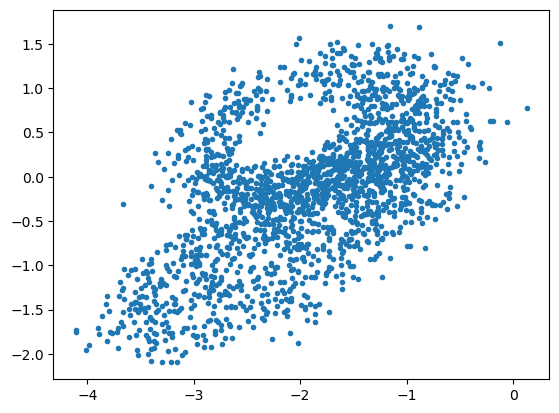

In [13]:
plt.plot(x[:, 0], x[:, 1], ".")

In [14]:
df_data = pd.DataFrame(
    index=np.arange(1),
    columns=["A", "B", "z", "x", "x_input"],
)
df_data.iloc[0] = [
    A,
    B,
    z,
    x,
    x_input,
]

In [15]:
df_data.to_pickle("data.pkl")

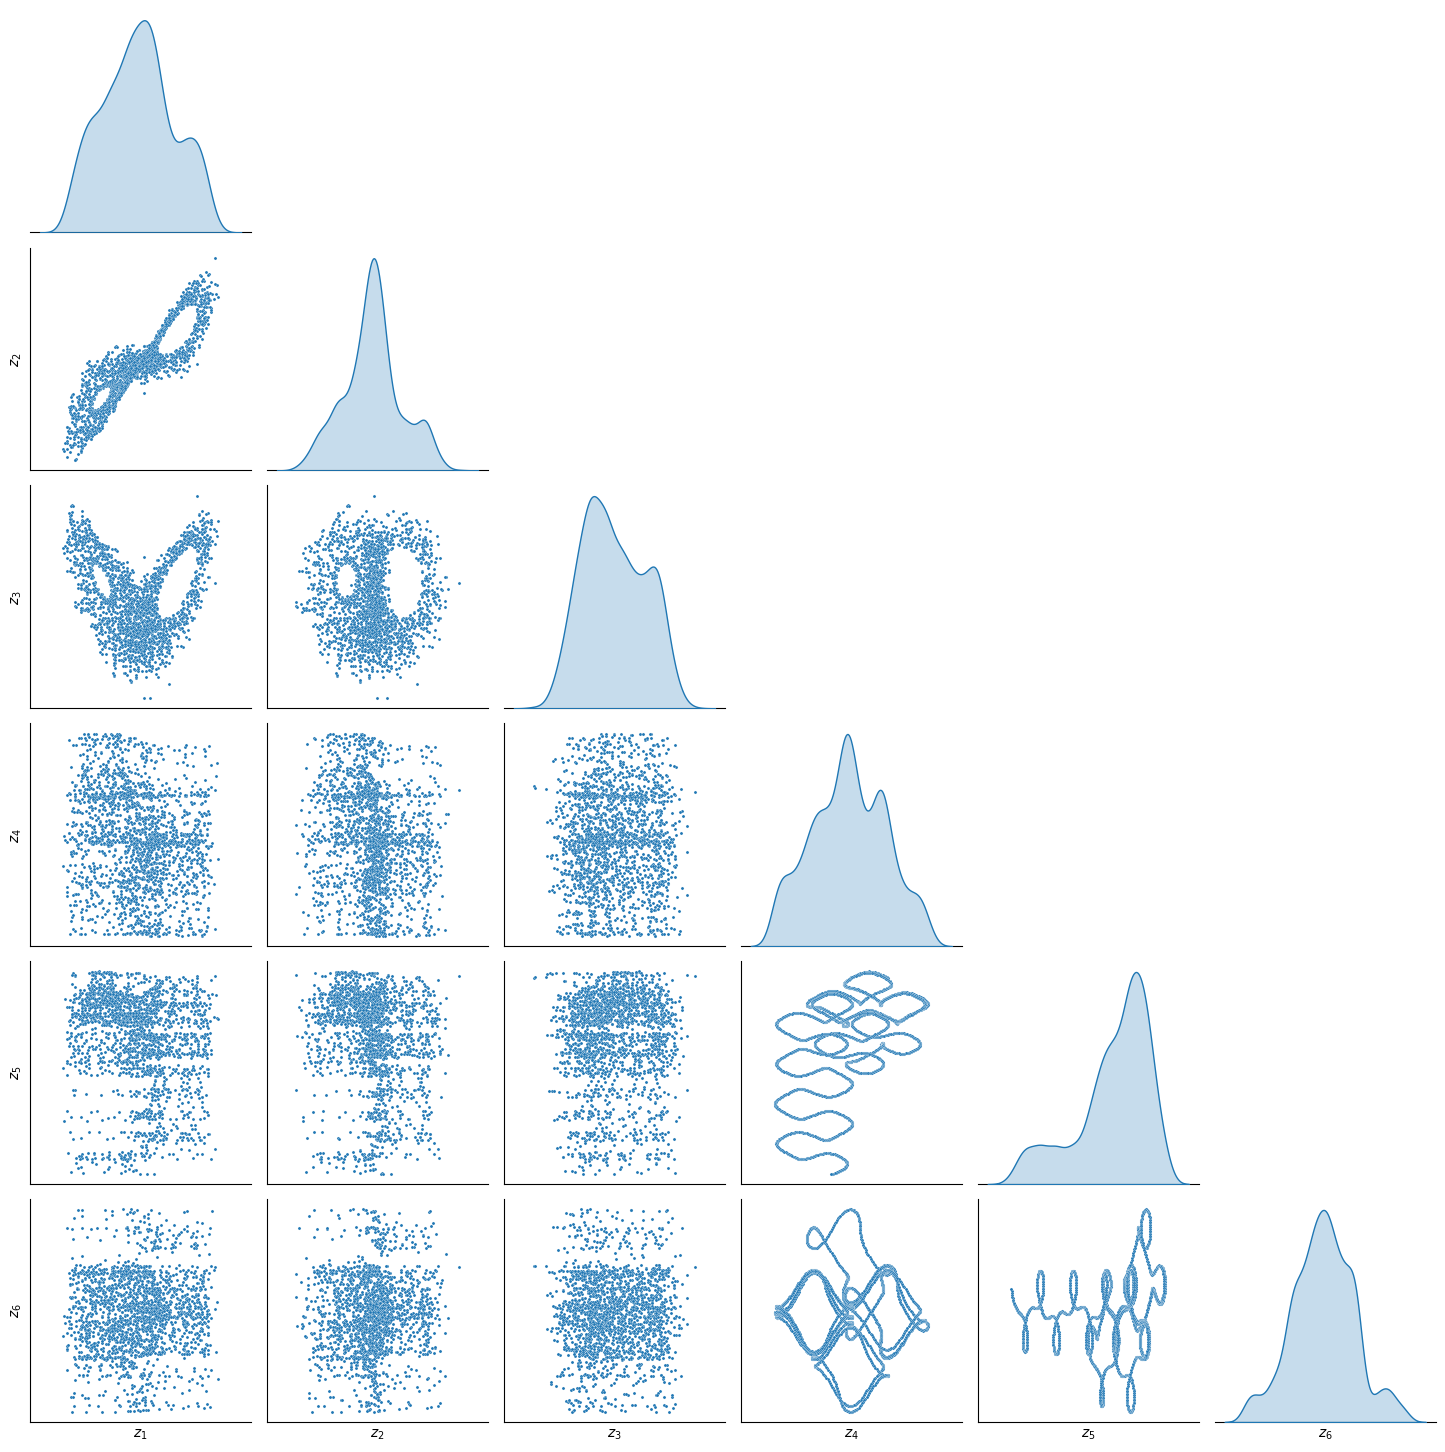

In [32]:
df_temp = pd.DataFrame(z.numpy(), columns=[f"$z_{i+1}$" for i in range(z.shape[1])])
g = sns.pairplot(df_temp, corner=True, diag_kind="kde", plot_kws=dict(s=5, alpha=1))

for i in range(n_components):
    for j in range(i + 1):
        ax = g.axes[i, j]
        ax.set_xticks([])
        ax.set_yticks([])
g.savefig("synthetic_data_2.pdf", transparent=True)